# SIGReg Masking and View Strategy (`input_pipeline.py` + `train.py`)

This notebook documents the **current implementation** of spectrum masking and two-view construction after moving augmentation into the TF input pipeline.

Coverage:
- `input_pipeline._augment_masked_view_tf` (masked view) and `_augment_unmasked_view_tf` (jitter-only view)
- fused batch fields emitted by `_augment_sigreg_batch_tf`
- how `train.py` consumes pre-augmented tensors via `forward_augmented()`
- how `tune.py` names/handles related hyperparameters


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from input_pipeline import TfLightningDataModule, numpy_batch_to_torch
from utils.training import load_config, build_model_from_config
from tune import generate_trial_configs, build_trial_run_name, _PARAM_ABBREVS

tf.config.set_visible_devices([], 'GPU')
sns.set_theme(style='whitegrid')
torch.set_printoptions(precision=4, sci_mode=False)

2026-02-14 02:44:56.454035: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-14 02:44:56.488555: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-02-14 02:44:57.457157: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load config + instantiate model

In [2]:
cfg = load_config('../configs/gems_a_50_mask.py')
cfg.tfrecord_dir = "../" + cfg.tfrecord_dir
model = build_model_from_config(cfg).eval()
strategy_cfg = {
    'sigreg_contiguous_mask_fraction': float(cfg.sigreg_contiguous_mask_fraction),
    'sigreg_contiguous_mask_min_len': int(cfg.sigreg_contiguous_mask_min_len),
    'sigreg_mz_jitter_std': float(cfg.sigreg_mz_jitter_std),
    'sigreg_intensity_jitter_std': float(cfg.sigreg_intensity_jitter_std),
    'num_peaks': int(cfg.num_peaks),
    'peak_ordering': str(cfg.peak_ordering),
}
strategy_cfg

{'sigreg_contiguous_mask_fraction': 0.25,
 'sigreg_contiguous_mask_min_len': 1,
 'sigreg_mz_jitter_std': 0.0001,
 'sigreg_intensity_jitter_std': 0.001,
 'num_peaks': 60,
 'peak_ordering': 'mz'}

## 2. Pull one real augmented batch from the TF pipeline

In [3]:
seed = int(cfg.seed)
dm = TfLightningDataModule(cfg, seed=seed)
train_ds = dm._build_massspec_train_dataset(seed=seed)
np_batch = next(train_ds.as_numpy_iterator())
batch = numpy_batch_to_torch(np_batch)

{k: tuple(v.shape) if isinstance(v, torch.Tensor) else type(v) for k, v in batch.items()}


2026-02-14 02:44:59.513771: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 250000


{'mz': (512, 60),
 'intensity': (512, 60),
 'rt': (512,),
 'precursor_mz': (512,),
 'peak_valid_mask': (512, 60),
 'peak_mz': (512, 60),
 'peak_intensity': (512, 60),
 'fused_mz': (1024, 60),
 'fused_intensity': (1024, 60),
 'fused_precursor_mz': (1024,),
 'fused_valid_mask': (1024, 60),
 'fused_masked_positions': (1024, 60),
 'view1_masked_fraction': numpy.float32}

In [4]:
batch["mz"][0]

tensor([180.0650, 376.3490, 458.3770,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000])

In [5]:
batch["intensity"][12]

tensor([0.0254, 0.0065, 0.0058, 0.0866, 0.5818, 0.0098, 0.0829, 0.0577, 0.3578,
        0.0635, 0.0112, 0.0266, 0.1922, 0.0210, 0.0182, 0.1628, 1.0000, 0.0099,
        0.0109, 0.0330, 0.0896, 0.0143, 0.0325, 0.1661, 0.0060, 0.0345, 0.0241,
        0.0077, 0.0123, 0.0157, 0.0122, 0.0156, 0.0093, 0.0197, 0.0659, 0.0398,
        0.2564, 0.0071, 0.0067, 0.0101, 0.0417, 0.0265, 0.0154, 0.0133, 0.0271,
        0.0067, 0.0074, 0.0061, 0.0069, 0.0067, 0.0060, 0.0066, 0.0626, 0.0211,
        0.0125, 0.0082, 0.0061, 0.0079, 0.0084, 0.0066])

In [6]:
batch['peak_valid_mask'][0]

tensor([ True,  True,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False])

In [7]:
valid_counts = batch['peak_valid_mask'].sum(dim=1)
sample_idx = 16
print('Selected sample index:', sample_idx)
print('Valid peaks in selected sample:', int(valid_counts[sample_idx]))

Selected sample index: 16
Valid peaks in selected sample: 14


## 3. Helper functions for sorted-span checks and plotting

In [8]:
def sorted_span_for_sample(peak_mz, peak_valid_mask, row):
    valid_idx = torch.nonzero(peak_valid_mask[row], as_tuple=False).squeeze(-1)
    sorted_valid_idx = valid_idx[torch.argsort(peak_mz[row, valid_idx])]
    start, end = 0, int(max(sorted_valid_idx.numel() - 1, 0))
    return sorted_valid_idx, int(start), int(end)

def contiguous_in_sorted_order(masked_row, sorted_valid_idx):
    pos = torch.nonzero(masked_row[sorted_valid_idx], as_tuple=False).squeeze(-1)
    if pos.numel() <= 1:
        return True, pos
    return bool(torch.all(pos[1:] - pos[:-1] == 1)), pos

def plot_three_views(orig_mz, orig_int, valid, v1_mz, v1_int, v1_masked, v2_mz, v2_int, title=''):
    x = torch.arange(orig_mz.shape[0])
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    axes[0].bar(x[valid], orig_int[valid].cpu().numpy(), color='#3B82F6', alpha=0.8)
    axes[0].set_title('Original intensity (valid peaks only)')

    jitterable = valid & (~v1_masked)
    axes[1].bar(x[jitterable], v1_int[jitterable].cpu().numpy(), color='#10B981', alpha=0.8, label='jittered')
    axes[1].bar(x[v1_masked], torch.ones_like(v1_int[v1_masked]).cpu().numpy() * 0.02, color='#EF4444', alpha=0.9, label='masked')
    axes[1].set_title('View 1: masked + jittered')
    axes[1].legend(loc='upper right')

    axes[2].bar(x[valid], v2_int[valid].cpu().numpy(), color='#F59E0B', alpha=0.8)
    axes[2].set_title('View 2: unmasked jitter-only')

    axes[2].set_xlabel('Peak slot index')
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## 4. Read both views from pipeline-produced fused tensors

In [9]:
batch.keys()

dict_keys(['mz', 'intensity', 'rt', 'precursor_mz', 'peak_valid_mask', 'peak_mz', 'peak_intensity', 'fused_mz', 'fused_intensity', 'fused_precursor_mz', 'fused_valid_mask', 'fused_masked_positions', 'view1_masked_fraction'])

In [10]:
batch_size = batch['peak_mz'].shape[0]

v1_mz = batch['fused_mz'][:batch_size]
v1_int = batch['fused_intensity'][:batch_size]
v1_valid = batch['fused_valid_mask'][:batch_size]
v1_masked = batch['fused_masked_positions'][:batch_size]

v2_mz = batch['fused_mz'][batch_size:]
v2_int = batch['fused_intensity'][batch_size:]
v2_valid = batch['fused_valid_mask'][batch_size:]
v2_masked = batch['fused_masked_positions'][batch_size:]

masked_fraction = batch['view1_masked_fraction']

print('masked_fraction:', float(masked_fraction))
print('masked positions in view2:', int(v2_masked.sum()))
print('view1_valid == peak_valid_mask:', bool((v1_valid == batch['peak_valid_mask']).all()))
print('view1_valid == peak_valid_mask & ~view1_masked:', bool((v1_valid == (batch['peak_valid_mask'] & (~v1_masked))).all()))


masked_fraction: 0.30677005648612976
masked positions in view2: 0
view1_valid == peak_valid_mask: False
view1_valid == peak_valid_mask & ~view1_masked: True


In [11]:
v2_valid[0].sum()

tensor(3)

In [12]:
row = sample_idx
batch['fused_masked_positions'][row]


tensor([False, False, False,  True,  True,  True, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False])

In [13]:
row = sample_idx
batch['fused_masked_positions'][row + batch['peak_mz'].shape[0]]


tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False])

In [14]:
batch['peak_valid_mask'][row]

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False])

In [15]:
batch['peak_mz'][row]

tensor([0.0030, 0.0050, 0.0060, 0.0217, 0.0304, 0.0409, 0.0440, 0.0471, 0.0758,
        0.0856, 0.1077, 0.1196, 0.1401, 0.1558, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000])

In [16]:
batch['peak_intensity'][row]

tensor([0.0251, 0.1735, 0.0294, 0.0256, 0.0260, 0.0275, 0.3211, 0.0335, 0.0281,
        0.0251, 0.0255, 0.0223, 0.0222, 0.0279, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000])

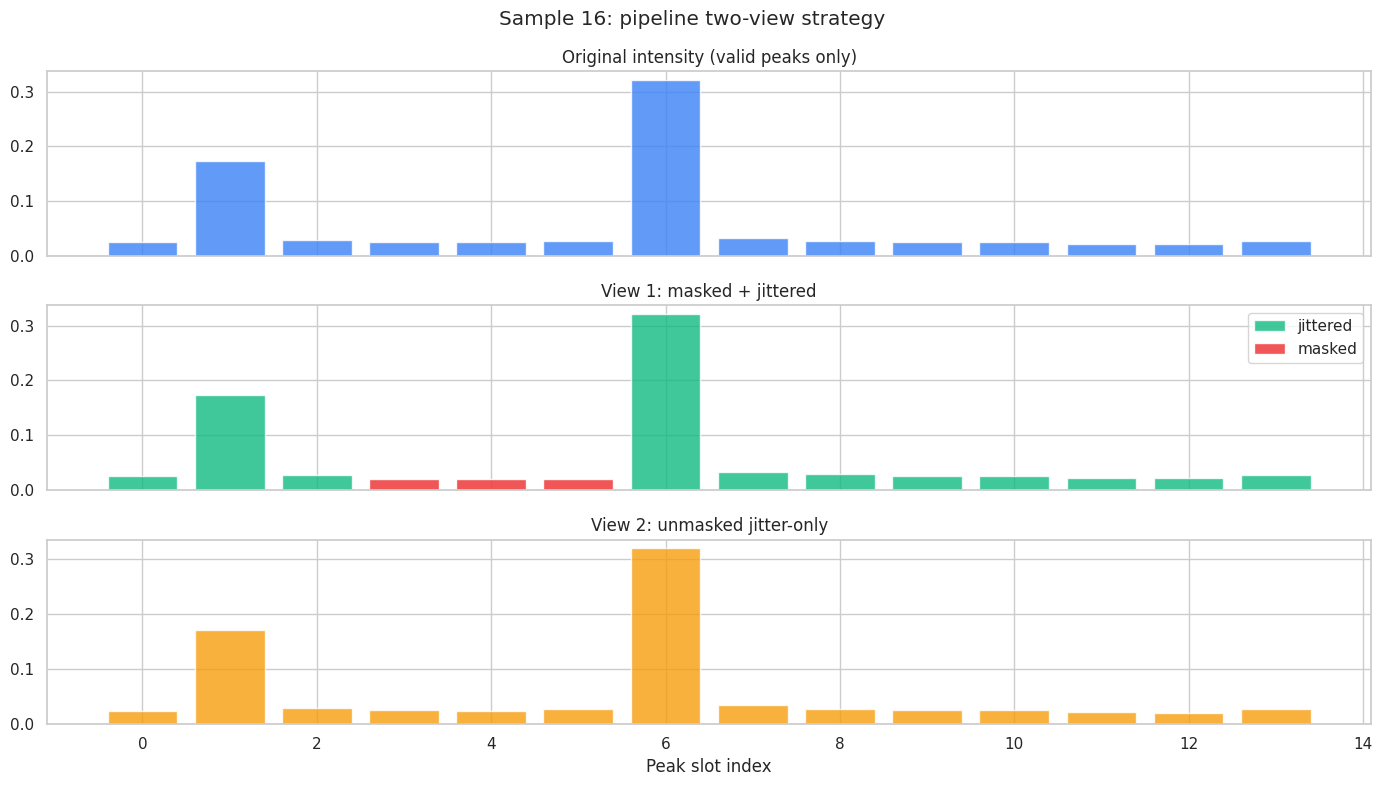

In [17]:
row = sample_idx
plot_three_views(
    batch['peak_mz'][row],
    batch['peak_intensity'][row],
    batch['peak_valid_mask'][row],
    v1_mz[row],
    v1_int[row],
    v1_masked[row],
    v2_mz[row],
    v2_int[row],
    title=f'Sample {row}: pipeline two-view strategy',
)


In [18]:
batch['peak_valid_mask'][row]

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False])

In [19]:
v1_masked[row]

tensor([False, False, False,  True,  True,  True, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False])

## 5. Inspect contiguity and density-interval constraints

In [20]:
row = sample_idx
sorted_valid_idx, interval_start, interval_end = sorted_span_for_sample(
    batch['peak_mz'], batch['peak_valid_mask'], row
)
is_contiguous, masked_pos = contiguous_in_sorted_order(v1_masked[row], sorted_valid_idx)

print('Sorted valid span in mz order:', (interval_start, interval_end))
print('Masked positions (in mz-sorted valid peaks):', masked_pos.tolist())
print('Contiguous mask in sorted order:', is_contiguous)

if masked_pos.numel() > 0:
    print('Mask inside sorted valid span:', int(masked_pos.min()) >= interval_start and int(masked_pos.max()) <= interval_end)

Sorted valid span in mz order: (0, 13)
Masked positions (in mz-sorted valid peaks): [3, 4, 5]
Contiguous mask in sorted order: True
Mask inside sorted valid span: True


In [21]:
all_contiguous = []
all_inside_span = []
for r in range(v1_masked.shape[0]):
    sorted_valid_idx, s, e = sorted_span_for_sample(batch['peak_mz'], batch['peak_valid_mask'], r)
    contiguous, pos = contiguous_in_sorted_order(v1_masked[r], sorted_valid_idx)
    all_contiguous.append(contiguous)
    if pos.numel() == 0:
        all_inside_span.append(True)
    else:
        all_inside_span.append(int(pos.min()) >= s and int(pos.max()) <= e)

print('All rows contiguous:', all(all_contiguous))
print('All rows masked inside sorted valid span:', all(all_inside_span))
print('Masked subset of valid:', bool((v1_masked <= batch['peak_valid_mask']).all()))

All rows contiguous: False
All rows masked inside sorted valid span: True
Masked subset of valid: True


## 6. Batch-level behavior over repeated pipeline augmentations

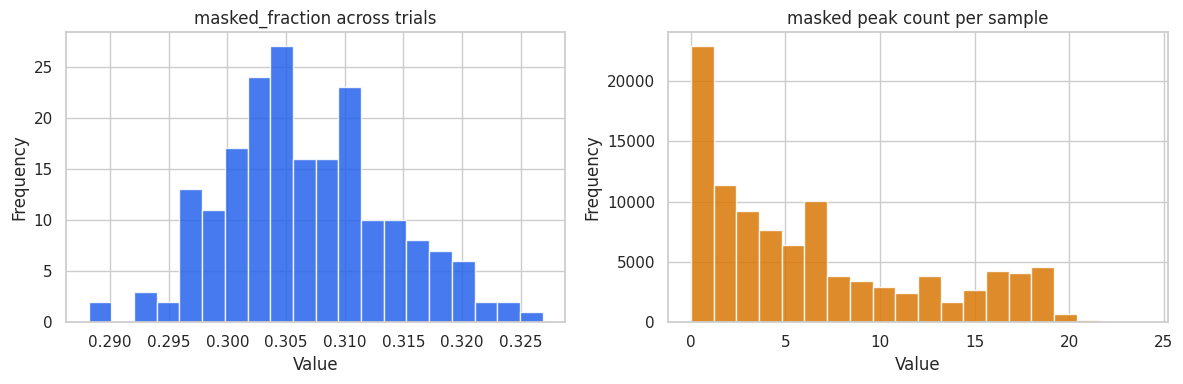

masked_fraction mean/std: 0.30671488657593726 0.007067714534035763


In [22]:
num_trials = 200
masked_fraction_hist = []
masked_count_hist = []

trial_iter = dm._build_massspec_train_dataset(seed=seed + 10_000).as_numpy_iterator()
for _ in range(num_trials):
    trial_batch = numpy_batch_to_torch(next(trial_iter))
    trial_bs = trial_batch['peak_mz'].shape[0]
    trial_view1_masked = trial_batch['fused_masked_positions'][:trial_bs]

    masked_fraction_hist.append(float(trial_batch['view1_masked_fraction']))
    per_row_counts = trial_view1_masked.sum(dim=1).float()
    masked_count_hist.extend(per_row_counts.tolist())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(masked_fraction_hist, bins=20, color='#2563EB', alpha=0.85)
axes[0].set_title('masked_fraction across trials')

axes[1].hist(masked_count_hist, bins=20, color='#D97706', alpha=0.85)
axes[1].set_title('masked peak count per sample')

for ax in axes:
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print('masked_fraction mean/std:', np.mean(masked_fraction_hist), np.std(masked_fraction_hist))


## 7. `forward_augmented()` consumption and train-time metrics

In [23]:
batch_size = batch['peak_mz'].shape[0]
view1_masked = batch['fused_masked_positions'][:batch_size]
view2_masked = batch['fused_masked_positions'][batch_size:]

print('fused_mz shape:', tuple(batch['fused_mz'].shape))
print('fused_valid shape:', tuple(batch['fused_valid_mask'].shape))
print('masked count view1:', int(view1_masked.sum().item()))
print('masked count view2:', int(view2_masked.sum().item()))
print('masked count fused second half:', int(batch['fused_masked_positions'][batch_size:].sum().item()))


fused_mz shape: (1024, 60)
fused_valid shape: (1024, 60)
masked count view1: 3333
masked count view2: 0
masked count fused second half: 0


In [24]:
projection = model.sample_bcs_projection(device=batch['peak_mz'].device, seed=7)
metrics = model.forward_augmented(batch, bcs_projection=projection)

metric_keys = [
    'loss',
    'bcs_loss',
    'invariance_loss',
    'valid_fraction',
    'masked_fraction',
    'alignment',
    'uniformity',
    'representation_variance',
    'encoder_variance',
]

for k in metric_keys:
    value = metrics[k].detach() if torch.is_tensor(metrics[k]) else metrics[k]
    print(f'{k:>25}: {float(value):.6f}')


/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/torch/nn/attention/flex_attention.py:1624: UserWarning: flex_attention called without torch.compile() - this will use an unfused implementation that materializes the full scores matrix instead of generating a fused kernel.

SOLUTION: Use torch.compile(flex_attention)(...)

If you want to debug your score_mod/mask_mod, you can set:
torch.nn.attention.flex_attention._FLEX_ATTENTION_DISABLE_COMPILE_DEBUG = True

This will allow you to use print statements or breakpoints. Note: This doesn't work with the backwards pass and may produce incorrect results.
  _warn_once(


                     loss: 0.077352
                 bcs_loss: 0.360292
          invariance_loss: 0.041323
           valid_fraction: 0.333122
          masked_fraction: 0.306770
                alignment: 0.834856
               uniformity: 0.485654
  representation_variance: 0.064312
         encoder_variance: 0.563343


`train.py` consumes pre-augmented fields from the dataloader (`fused_mz`, `fused_intensity`, `fused_valid_mask`, `fused_masked_positions`, `view1_masked_fraction`) and logs training metrics such as `train/loss` and `train/masked_fraction`.


## 8. `tune.py` integration for masking-related hyperparameters

In [25]:
print('Current tune_param_space from config:')
print(list(cfg.tune_param_space))
print()
print('Mask/view-related abbreviations in tune.py:')
for key in sorted(_PARAM_ABBREVS):
    if 'mask' in key:
        print(f'  {key} -> {_PARAM_ABBREVS[key]}')

Current tune_param_space from config:
[{'param': 'weight_decay', 'dist': 'grid', 'args': [0.0001, 0.001, 0.01]}, {'param': 'sigreg_lambda', 'dist': 'grid', 'args': [1.0]}]

Mask/view-related abbreviations in tune.py:
  sigreg_contiguous_mask_fraction -> cmf


In [26]:
example_space = [
    {'param': 'sigreg_contiguous_mask_fraction', 'dist': 'grid', 'args': [0.15, 0.25]},
]
trial_cfgs = generate_trial_configs(example_space, num_samples=1, seed=42)
for idx, trial in enumerate(trial_cfgs):
    print(build_trial_run_name(idx, trial), trial)

tune-000-cmf=0.15 {'sigreg_contiguous_mask_fraction': 0.15}
tune-001-cmf=0.25 {'sigreg_contiguous_mask_fraction': 0.25}


## 9. Summary

The current strategy is:
1. Build two views per spectrum inside `input_pipeline.py`: **masked+jittered** view and **unmasked jitter-only** view.
2. In the masked view, sort valid peaks by m/z and treat the full valid sorted span as eligible, then mask a contiguous sub-span with length controlled by `sigreg_contiguous_mask_fraction` and `sigreg_contiguous_mask_min_len`.
3. Drop masked peaks from the masked-view validity (`view1_valid = peak_valid_mask & ~masked`) and emit pre-fused tensors (`fused_*`) plus `view1_masked_fraction`.
4. `train.py` forwards these tensors through one fused encoder/pool/projector pass via `model.forward_augmented(...)`, then applies SIGReg loss on `(z1, z2)`.
5. `tune.py` can sweep masking-related hyperparameters and names runs using short abbreviations (`cmf`).


In [27]:
import pandas as pd

In [28]:
df = pd.DataFrame()